# Disciplina de IA - BCC 2026, IBILCE/UNESP
---
# <font color='red'>Notebook python para trabalhar com as implementações das aulas</font>
---

## 1. Preliminares

In [ ]:
#Importando bibliotecas clássicas do Python
import pandas as pd
import numpy as np
import statistics as st
import matplotlib.pyplot as plt
import plotly.express as px

#Importanto bibliotecas de aprendizado de máquina (ainda não visto)
#from sklearn import preprocessing
#from sklearn.preprocessing import RobustScaler
#from sklearn.decomposition import PCA

#Montando a partição do Google Drive
file_path = './dados_banco.csv'

#Abrindo um arquivo (tabular) do tipo csv
df = pd.read_csv(file_path, delimiter=",")

#Imprime os primeiros registros do data_frame
df.head()

Mounted at /content/drive


,Cliente,Sexo,Idade,Empresa,Salario,Saldo_cc,Saldo_poupanÃ§a,Saldo_investimento,Devedor_cartao,Inadimplente
0,1,M,33,Privada,6019,"1084,98","0,00","0,00","1214,35",0
1,2,F,31,Pública,5134,"532,09","0,00","0,00","1662,96",0
2,3,M,31,Pública,5286,"719,91","0,00","0,00","2167,97",0
3,4,F,32,Privada,5534,"547,47","0,00","0,00","639,13",1
4,5,F,28,Autônomo,4559,"412,81","0,00","0,00","1466,96",1


In [2]:
# Verificar os tipos de dados originais
print('Dados brutos - tipos\n', df.dtypes)

#Substituição de ',' por '.' e conversao p/ float64
cols_p_converter = ['Saldo_cc', 'Saldo_poupanÃ§a', 'Saldo_investimento', 'Devedor_cartao']
for col in cols_p_converter:
    df[col] = df[col].str.replace(',', '.').astype('float64')

#Remove a coluna cliente#
df.drop(columns=['Cliente'], inplace=True)

# Verificar os tipos de dados após a conversão
print('\nDados convertiso - tipos\n', df.dtypes)

#Imprime os últimos registros do data_frame
df.tail()

Dados brutos - tipos
 Cliente                int64
Sexo                  object
Idade                  int64
Empresa               object
Salario                int64
Saldo_cc              object
Saldo_poupanÃ§a       object
Saldo_investimento    object
Devedor_cartao        object
Inadimplente           int64
dtype: object

Dados convertiso - tipos
 Sexo                   object
Idade                   int64
Empresa                object
Salario                 int64
Saldo_cc              float64
Saldo_poupanÃ§a       float64
Saldo_investimento    float64
Devedor_cartao        float64
Inadimplente            int64
dtype: object


,Sexo,Idade,Empresa,Salario,Saldo_cc,Saldo_poupanÃ§a,Saldo_investimento,Devedor_cartao,Inadimplente
99995,F,31,Autônomo,5246,650.93,0.00,0.00,2083.84,1
99996,M,32,Privada,5678,877.58,16881.08,9482.21,0.00,0
99997,M,31,Pública,5430,627.46,0.00,0.00,1239.22,0
99998,F,30,Pública,5070,573.75,0.00,0.00,3427.16,0
99999,M,31,Autônomo,5323,456.93,0.00,0.00,3119.86,0


## 2. Estatística Descritiva

**Estatística Descritiva:** tem como finalidade sumarizar quantitativamente as principais características de um conjunto de dados a partir de medidas e ferramentas estatísticas.

## Principais medidas/ferramentas estatísticas

- **Medidas de posição**
    - **Média**: média dos valores
    - **Mediana:** valor de posição central
    - **Moda:** valor mais frequente
    - **Quantis:** caracterização em partes da distribuição dos dados

- **Medidas de dispersão**
    - **Desvio-padrão:** mede quão distante os valores estão da média
    - **Variância:** similar ao caso acima (é o desvio-padrão ao quadrado)
    - **Amplitude (range):** Valor máximo - valor mínimo
    - **Coeficiente de variação:** medida de dispersão relativa
    - **Interquartile Range (IQR):** diferença entre o terceiro quartil (Q3) e o primeiro quartil (Q1)

- **Gráficos de boxplot**

- **Medidas de associação**
    - **Covariância**
    - **Coeficiente de correlação de Pearson**
    - **Coeficiente de correlação de Spearman**
    - **Razão de chances (Odds Ratio)**




In [18]:
#Medidas de posição
print('Medidas de posição')

# Média para cada coluna
media = df.mean(numeric_only=True)
print(media)
#df['Idade'].mean() # exemplo de média de apenas uma coluna

# Cálculo % da quantidade de grupos ref. ao atributo 'Sexo'
x = df['Sexo'].value_counts()
print('\nGrupos por', x/len(df))

# Moda: valor que mais aparece
#moda = df.mode()
#print("Moda de cada coluna:\n", moda.iloc[0])

#Medidas de dispersão
print('\nMedidas de dispersão')
v = df['Salario'].var()
d = df['Salario'].std()
print('Variância: ', v)
print('Desvio padrão ', d)

Medidas de posição
Idade                   31.831740
Salario               5514.294290
Saldo_cc               836.535376
Saldo_poupanÃ§a       2213.296334
Saldo_investimento    1471.116085
Devedor_cartao        2408.638706
Inadimplente             0.243590
dtype: float64

Grupos por Sexo
M    0.58155
F    0.41845
Name: count, dtype: float64

Medidas de dispersão
Variância:  226369.7988213805
Desvio padrão  475.78335282077757


In [4]:
#Calculando várias estatísticas de uma só vez
df.describe().astype(int)

,Idade,Salario,Saldo_cc,Saldo_poupanÃ§a,Saldo_investimento,Devedor_cartao,Inadimplente
count,100000,100000,99998,100000,100000,100000,100000
mean,31,5514,836,2213,1471,2408,0
std,2,475,238,5650,3914,1659,0
min,-31,4359,-280,0,0,0,0
25%,30,5235,675,0,0,1100,0
50%,32,5530,835,0,0,2463,0
75%,34,5766,996,0,0,3602,0
max,56,90800,2340,27329,22803,10281,1


## Quartil e Percentil

**a) Quartil:** segmenta os dados em quartos partes

- **1º quartil (Q1):** valor-referência que reúne **25%** dos dados **abaixo** dele.
- **2º quartil (Q2):** mediana (**50%** abaixo).
- **3º quartil (Q3):** valor-referência que reúne **75%** dos dados **abaixo** dele.

**b) Percentil:** Generaliza os quartils para um 'p' entre 0 e 100.

- **p percentil:** $x_i$ tal que p% dos valores observados são **menores** do que $x_i$.
- **p = 25%:** Q1.
- **p = 50%:** Q2 = mediana.
- **p = 75%:** Q3.

Exemplo:

$X = \{9, 3, 11, 14, 20, 4, 6, 17, 30, 21, 23, 16\}$

1) Ordenar os dados. \\
2) tomar o valor central (Q2), depois o valor central à esquerda (Q1) e também à direita (Q3).

3 4 6 $|_{Q_1}$ 9 11 14 $|_{Q_2}$ 16 17 20 $|_{Q_3}$ 21 23 30

Q1 = 7,5; Q2 = 15; Q3 = 20,5




## Boxplot

**Boxplot:** gráfico que possibilita visualizar os quartis, possibilitando analisar o formato ("grau de compactação") e distribuição dos dados.

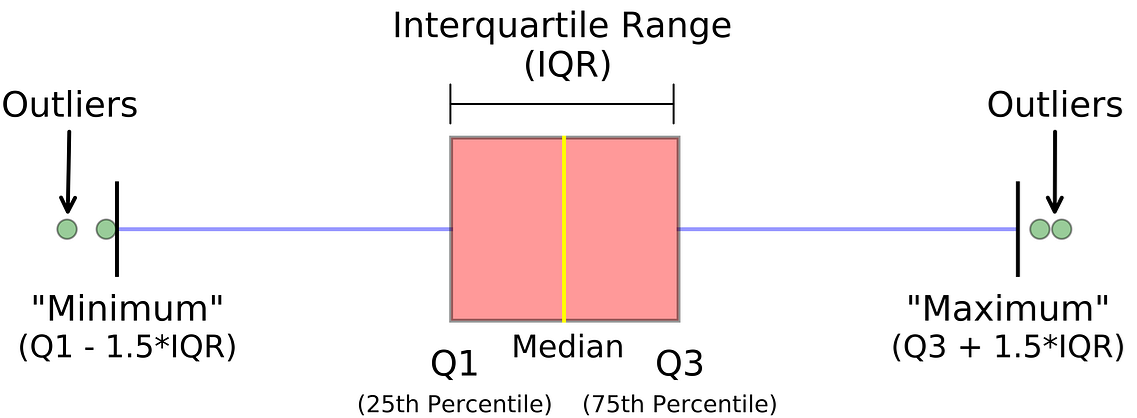

Text(0, 0.5, 'Valores')

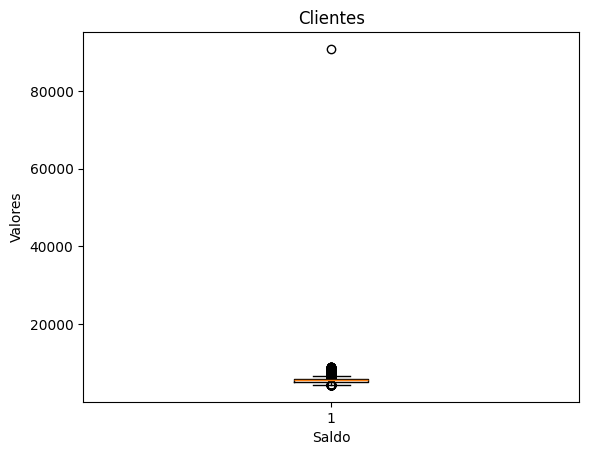

In [19]:
#Remoção do objeto outlier
#df = df.drop(index=df['Salario'].idxmax())

# Gráfico boxplot
plt.boxplot(df['Salario'])
plt.title('Clientes')
plt.xlabel('Saldo')
plt.ylabel('Valores')

## Bigodes vs. Outliers

**Bigodes (Whiskers):**
- Os bigodes geralmente se estendem até 1.5 vezes o IQR (Q3 + 1.5 * IQR para cima, e Q1 - 1.5 * IQR para baixo).
- Os valores dentro desses intervalos são considerados "não-outliers", e ficam dentro do alcance esperado.

**Dados Discrepantes (Outliers):**
- Em geral, os outliers são caracterizados como valores "significativamente maiores" que o valor-limite no bigode superior (Q3 + 1.5 * IQR), ou "significativamente menores" que o valor-limite no bigode inferior (Q1 - 1.5 * IQR).

Text(0, 0.5, 'Valores')

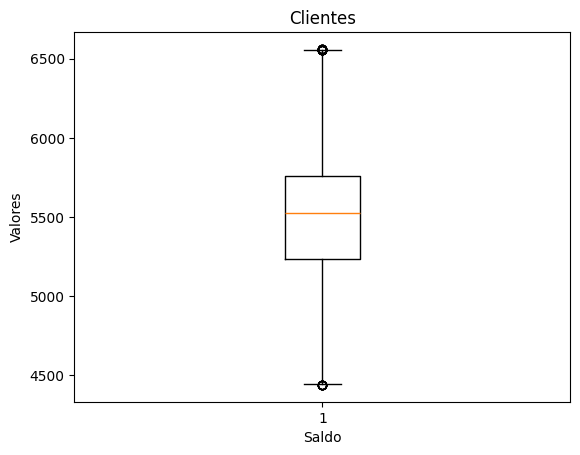

In [25]:
# Removendo os outliers com base nos limites dos bigodes
# Calcula o IQR
Q1 = df['Salario'].quantile(0.25)
Q3 = df['Salario'].quantile(0.75)
IQR = Q3 - Q1

# Calcular os limites inferior e superior
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filtrar os dados para remover os outliers
df_filtered = df[(df['Salario'] >= lower_bound) & (df['Salario'] <= upper_bound)]

plt.boxplot(df_filtered['Salario'])
plt.title('Clientes')
plt.xlabel('Saldo')
plt.ylabel('Valores')
# -------------------------------------------------------

## Medidas de associação

**Covariância:** mede o grau com que duas variáveis, $X=(X_i)$ e $Y=(Y_i)$, variam quando analisadas conjuntamente.

$$COV(X,Y) = \frac{1}{n} \sum_{i=1}^{n} (X_i - \bar{X}) (X_i - \bar{Y})$$


**Correlação de Pearson:** mede a relação de linearidade entre duas variáveis.

$$\rho(X,Y) = \frac{COV(X,Y)}{S_X S_Y} = \frac{\sum_{i=1}^{n} (X_i - \bar{X}) (X_i - \bar{Y})}{\sqrt{\sum_{i=1}^{n} (X_i - \bar{X})^2} \sqrt{\sum_{i=1}^{n} (Y_i - \bar{Y})^2}}$$

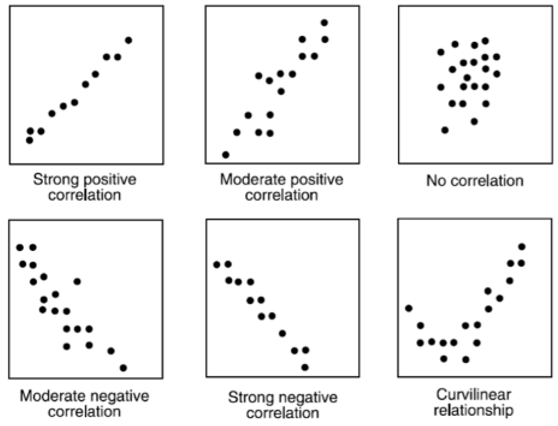

Text(0.5, 1.0, 'Gráfico de Dispersão')

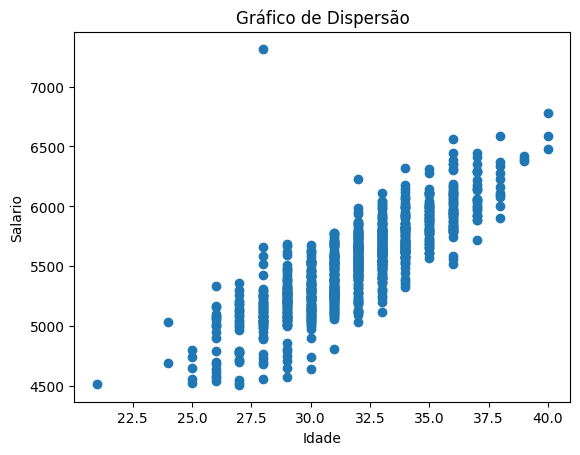

In [24]:
# Plotando o gráfico de dispersão (para investigar a correlação)
var_1, var_2 = 'Idade', 'Salario'
df_recorte = df.head(1000) #pega os 100 primeiros registros.
plt.scatter(df_recorte[var_1], df_recorte[var_2])
plt.xlabel(var_1)
plt.ylabel(var_2)
plt.title("Gráfico de Dispersão")

In [23]:
corr = df.corr(numeric_only=True)
corr.style.background_gradient(cmap='coolwarm').format(precision=4)

,Idade,Salario,Saldo_cc,Saldo_poupanÃ§a,Saldo_investimento,Devedor_cartao,Inadimplente
Idade,1.0000,0.7150,0.4639,0.0276,0.0273,0.0846,-0.0145
Salario,0.7150,1.0000,0.4598,0.0348,0.0323,0.0768,-0.0172
Saldo_cc,0.4639,0.4598,1.0000,0.0151,0.0153,0.0554,-0.0098
Saldo_poupanÃ§a,0.0276,0.0348,0.0151,1.0000,0.9595,-0.5685,-0.2223
Saldo_investimento,0.0273,0.0323,0.0153,0.9595,1.0000,-0.5455,-0.2133
Devedor_cartao,0.0846,0.0768,0.0554,-0.5685,-0.5455,1.0000,0.1581
Inadimplente,-0.0145,-0.0172,-0.0098,-0.2223,-0.2133,0.1581,1.0000


## Correlação - Observações

A correlação entre duas variáveis não implica necessariamente em uma relação de causa e efeito.

Existem três cenários possíveis em relação à correlação x causalidade:

**1. Causalidade:** Uma variável causa mudança na outra.

**2. Correlação sem causalidade:** Mesmo quando duas variáveis estão correlacionadas matematicamente, isso não significa necessariamente que uma causa a outra.
- Exemplos de correlação sem causalidade: https://www.tylervigen.com/spurious-correlations

**3. Causalidade sem correlação:** Às vezes, uma variável pode causar mudanças em outra sem que haja uma correlação linear evidente. Isso pode acontecer quando a relação não é linear, ou quando há muitos outros fatores afetando a relação.
- Exemplo: A eficácia de um medicamento depende da dose: doses baixas são ineficazes, doses moderadas são ideais, e doses altas são tóxicas. A relação entre dose e efeito é não linear, o que pode resultar em uma correlação baixa, apesar da causalidade evidente.

## 3. Outros gráficos e ferramentas de visualização

- Gráfcos de piza

- Histogramas

- Heat maps

- Star plots, Treemaps, stacked maps ...

- Grafos

In [26]:
#Exemplo (Star plot)
import plotly.express as px

# Filtrar por idade
df_aux = df[df['Idade'] < 30]

# Criar um DataFrame com os valores médios de cada atributo numérico racional
mean_values = df_aux[['Saldo_cc', 'Saldo_poupanÃ§a', 'Saldo_investimento']].mean()

# Criar o DataFrame para o gráfico do tipo star plot
data = {
    'r': mean_values.values, # Usando os valores médios das variáveis
    'theta': mean_values.index # Usando os nomes das variáveis como categorias
}
df_star = pd.DataFrame(data)

# Criar o gráfico do tipo star plot
fig = px.line_polar(df_star, r='r', theta='theta', line_close=True)
fig.update_traces(fill='toself')

# Exibir o gráfico
fig.show()

## Gráfico Star Plot - Interpretação

- As pontas do triângulo representam os valores médios das três variáveis para indivíduos com menos de 30 anos.
- O preenchimento do gráfico mostra a distribuição desses valores médios em relação umas às outras.
- A área sombreada dentro do gráfico indica os níveis relativos de cada variável.

**No exemplo**:
- Saldo_poupança possui um valor médio significativamente maior para as pessoas com menos de 30 anos em comparação com os outros dois saldos.
- Saldo_cc e Saldo_investimento têm valores médios relativamente menores.


## 4. Pré-processamento dos dados

- Eliminação (artesanal) de atributos

- Integração de dados

- Amostragem de dados

- Balanceamento de dados

- Sanitização de dados/remoção de outliers

- Redução de dimensionalidade

In [27]:
#Remove a coluna 'Cliente'
#df.head()
df.drop(columns=['Cliente'])

KeyError: "['Cliente'] not found in axis"

## Amostragem de dados

- **Representatividade**: A amostra deve refletir as características da população-alvo.
- **Tamanho da Amostra**: Deve ser "grande o suficiente" para garantir precisão e abrangência estatística.
- **Aleatoriedade**: Seleção aleatória dos dados para evitar vieses.
- **Estratificação**: Dividir a população em subgrupos relevantes e amostrar proporcionalmente.
- **Custo e Tempo**: Balancear a necessidade de dados com recursos disponíveis.
- **Objetivo do Estudo**: Escolher o método de amostragem adequado ao tipo de objetivo.

In [ ]:
#Amostragem aleatória com 4 amostras (pessoas inadimplentes)
df.loc[df['Inadimplente'] == 1].sample(n=4)

,Sexo,Idade,Empresa,Salario,Saldo_cc,Saldo_poupanÃ§a,Saldo_investimento,Devedor_cartao,Inadimplente
11036,F,31,Privada,5551,932.43,0.0,0.0,5928.41,1
58300,M,33,Privada,5487,678.51,0.0,0.0,1740.86,1
49846,F,30,Pública,5286,624.61,0.0,0.0,2463.83,1
44612,F,33,Privada,5610,1004.78,0.0,0.0,3569.71,1


## Limpeza dos dados

In [ ]:
#Quantidade de valores faltantes para todos os atributos
print('Valores faltantes:\n', df.isnull().sum())

Valores faltantes:
 Sexo                  0
Idade                 0
Empresa               0
Salario               0
Saldo_cc              2
Saldo_poupanÃ§a       0
Saldo_investimento    0
Devedor_cartao        0
Inadimplente          0
dtype: int64


In [ ]:
#Filtrando os 'NaN'
print('Not a number:\n', df.isna().sum())

Not a number:
 Cliente               0
Sexo                  0
Idade                 0
Empresa               0
Salario               0
Saldo_cc              2
Saldo_poupanÃ§a       0
Saldo_investimento    0
Devedor_cartao        0
Inadimplente          0
dtype: int64


In [ ]:
#Quantidade de valores duplicados para todos os atributos
#True: linha duplicada (que está aparecendo pela segunda vez ou mais); False: linha única
print('Valores duplicados:\n', df.duplicated())

Valores duplicados:
 0        False
1        False
2        False
3        False
4        False
         ...  
99995    False
99996    False
99997    False
99998    False
99999    False
Length: 100000, dtype: bool


In [ ]:
#Atribuição da média em registros com atributos faltantes (nesse ex, nao temos)
median = df['Saldo_cc'].median()
df['Saldo_cc'].fillna(median, inplace = True) #subtitui os elementos faltosos pela mediana
print('Valores faltantes:\n', df.isnull().sum())

Valores faltantes:
 Cliente               0
Sexo                  0
Idade                 0
Empresa               0
Salario               0
Saldo_cc              0
Saldo_poupanÃ§a       0
Saldo_investimento    0
Devedor_cartao        0
Inadimplente          0
dtype: int64


In [ ]:
#Elimina todas as linhas com dados ausentes (solução crítica)
#df = df.dropna(how ='any')
#Elimina todas as linhas com dados duplicados
#df.drop_duplicates()

## Transformação de dados
Etapa crucial no pré-processamento dos dados para aprendizado de máquina, preparando os dados para serem operados pelos modelos.

**Conversão entre tipos**
- **Label Encoding**: Converte variáveis qualitativas em valores numéricos inteiros. Cada categoria é mapeada para um número distinto. Bastnte útil para variáveis ordinais (Nível de febre: "Baixo", "Médio", "Alto" -> 0, 1, 2).
- **Ordinal Encoding**: Similar ao caso anterior, mas permite definir explicitamente a ordem das categorias.
- **One-Hot Encoding**: Converte variáveis categóricas em uma série de novas variáveis (colunas) binárias, ideal para variáveis nominais (cores, cidades, dias da semana)
- **Outras estratégias**: Binarização, discretização (conversão variáveis contínuas em categóricas), etc.

**Escalonamento**
- **Feature Scaling**: Ajuste de escala dos atributos visando uma única faixa comum para viablizar comparações no espaço de features.
 - **Min-Max (Normalização)**: Converte para a escala [0,1].
 - **Standarlization (Padronização)**: Converte para que os atributos tenham média 0 e desvio padrão 1.



In [ ]:
#Label encoding (transforma atributos qualitativos em quantitativos)
from sklearn import preprocessing
le = preprocessing.LabelEncoder()
for col in df.columns:
    if df[col].dtypes == 'object':
        df[col] = le.fit_transform(df[col])

df

,Cliente,Sexo,Idade,Empresa,Salario,Saldo_cc,Saldo_poupanÃ§a,Saldo_investimento,Devedor_cartao,Inadimplente
0,1,1,33,1,6019,1084.98,0.00,0.00,1214.35,0
1,2,0,31,2,5134,532.09,0.00,0.00,1662.96,0
2,3,1,31,2,5286,719.91,0.00,0.00,2167.97,0
3,4,0,32,1,5534,547.47,0.00,0.00,639.13,1
4,5,0,28,0,4559,412.81,0.00,0.00,1466.96,1
...,...,...,...,...,...,...,...,...,...,...
99995,99996,0,31,0,5246,650.93,0.00,0.00,2083.84,1
99996,99997,1,32,1,5678,877.58,16881.08,9482.21,0.00,0
99997,99998,1,31,2,5430,627.46,0.00,0.00,1239.22,0
99998,99999,0,30,2,5070,573.75,0.00,0.00,3427.16,0


In [ ]:
#Reescalomento via Standarlization (N(0,1))
from sklearn.preprocessing import StandardScaler
ss = StandardScaler()
X_stand = ss.fit_transform(df)
#print(X_stand)

#Veficidando se cada coluna foi convertida para uma distribuição N(0,1)
mean = X_stand.mean()
std_dev = X_stand.std()

In [ ]:
#Reescalomento via Normalization Min-Max
from sklearn.preprocessing import MinMaxScaler
mms = MinMaxScaler()
X_norm = mms.fit_transform(df)

#Vefificando se deu certo
x, y = X_norm.min(axis=0), X_norm.max(axis=0)
print(x)
print(y)

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
